# Law of Large Numbers

The law of large numbers (LLN) states that the average of the results of a large number of independent random samples converges to the expected value. The two main versions of the LLN are called the weak and the strong laws. Formally, the weak law of large numbers (WLLN) is defined as follows:

Let $X_1, X_2, X_3, ..., X_n$ be independent and identically distributedrandom variables with a finite expected value $E[X_i]=\mu<\infty$. Then for any $\epsilon>0$,
$$\lim_{n\rightarrow\infty}P(|\bar{X}-\mu|\geq\epsilon)=0$$

The law says that as $n\rightarrow\infty$, the probability that the difference between $\bar{X}$ and ${\mu}$ is greater than or equal to any $\epsilon$ vanishes. Or equivalently, the probability that $\bar{X}$ is close to ${\mu}$ is very large for large $n$.

In [2]:
import numpy.random as rand
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
def plotDistribution(distribution, *params):

    expectation = params[0]

    if distribution == "normal":
        xs = np.linspace(params[0]-5, params[0]+5, 500)
        ys = 1/np.sqrt(2*np.pi*params[1]**2)*np.exp(-((xs-params[0])**2)/(2*params[1]**2))

    if distribution == "exponential":
        xs = np.linspace(0, 10, 500)
        lam = 1/params[0]
        ys = lam*np.exp(-lam*xs)
   
    sns.scatterplot(x=xs, y=ys, size=1, legend=False)
    plt.plot([expectation,expectation], [0,1], c="r", label="Expectation")
    plt.legend()
    # plt.xlim(0,)
    plt.ylim(0, max(ys)+0.2*max(ys))

def plotAbsMeanMinusExpect(distribution, samples, expectedValue, *params):

    vals = []

    for i in range(1, samples+1):
        if distribution == "normal":
            sample = rand.normal(params[0], params[1], i)
        
        if distribution == "exponential":
            sample = rand.exponential(params[0], i)
            
        sampleMean = np.mean(sample)
        vals.append(np.absolute(sampleMean - expectedValue))
    
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.scatter(range(1, samples+1), vals, marker=1)

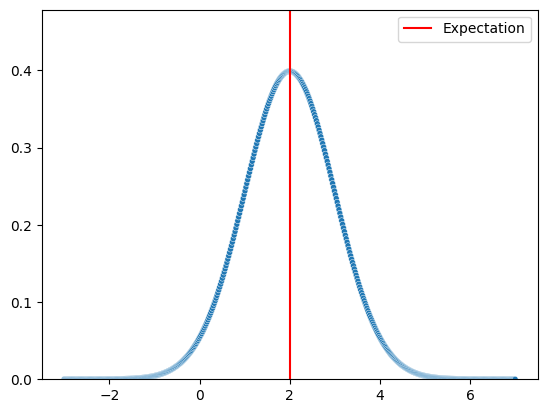

In [11]:
plotDistribution("normal", 2, 1)

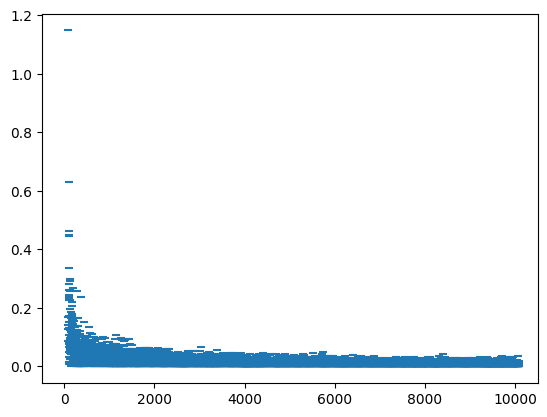

In [5]:
plotAbsMeanMinusExpect("normal", 10000, 2, 2, 1)

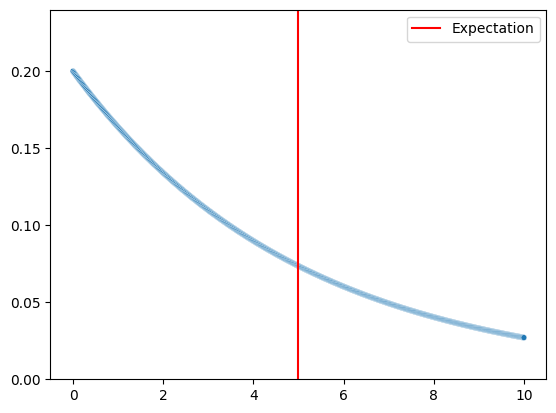

In [13]:
plotDistribution("exponential", 5)

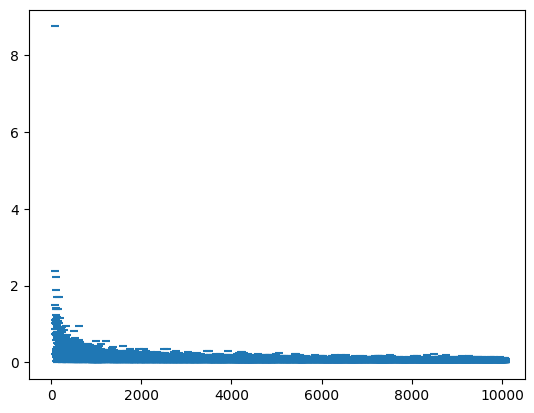

In [6]:
plotAbsMeanMinusExpect("exponential", 10000, 5, 5)